# Favorita Grocery Sales Forecasting —EDA



## 1. Проводим EDA по ноутбуку
Сначала посмотрим на общую динамику и убедимся, что задача действительно имеет:
- выраженную сезонность;
- много нулей;
- зависимость от промо.

In [14]:
import os
import gc
import math
import json
import random
import warnings
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_pacf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:

# -----------------------------
# Конфиг
# -----------------------------
SEED = 42
TRAIN_START_FOR_MODEL = "2016-07-01"   # ограничиваем историю для фичей и DL, чтобы ноутбук был реалистичен
VALID_START = "2017-08-01"
VALID_END   = "2017-08-15"
TEST_START  = "2017-08-16"
TEST_END    = "2017-08-31"

LAGS = [1, 7, 14, 28]
ROLL_WINDOWS = [7, 14, 28]

# Для DL-модели
ENC_LEN = 90
HORIZON = 16
DL_MAX_SERIES = 4000   # можно увеличить на Kaggle GPU/TPU, локально лучше оставить так

# Для демонстрации Theta/ETS
CLASSICAL_MAX_SERIES = 300

random.seed(SEED)
np.random.seed(SEED)

In [3]:

train_dtypes = {
    "id": "int64",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "unit_sales": "float32",
    "onpromotion": "bool",
}

test_dtypes = {
    "id": "int64",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "onpromotion": "bool",
}

stores_dtypes = {
    "store_nbr": "int16",
    "cluster": "int16",
}

items_dtypes = {
    "item_nbr": "int32",
    "class": "int32",
    "perishable": "int8",
}

transactions_dtypes = {
    "store_nbr": "int16",
    "transactions": "float32",
}

In [4]:


usecols_train = ["date", "store_nbr", "item_nbr", "unit_sales", "onpromotion"]
usecols_test = ["id", "date", "store_nbr", "item_nbr", "onpromotion"]

train = pd.read_csv(f"data/favorita-grocery-sales-forecasting/train.csv", parse_dates=["date"]).drop(columns=["id"])

test = pd.read_csv(
    f"data/favorita-grocery-sales-forecasting/test.csv",
    usecols=usecols_test,
    dtype=test_dtypes,
    parse_dates=["date"],
)

stores = pd.read_csv(f"data/favorita-grocery-sales-forecasting/stores.csv", dtype=stores_dtypes)
items = pd.read_csv(f"data/favorita-grocery-sales-forecasting/items.csv", dtype=items_dtypes)
oil = pd.read_csv(f"data/favorita-grocery-sales-forecasting/oil.csv", parse_dates=["date"])
transactions = pd.read_csv(f"data/favorita-grocery-sales-forecasting/transactions.csv", dtype=transactions_dtypes, parse_dates=["date"])
holidays = pd.read_csv(f"data/favorita-grocery-sales-forecasting/holidays_events.csv", parse_dates=["date"])

In [5]:

print("train shape:", train.shape)
print("test shape :", test.shape)
print("stores     :", stores.shape)
print("items      :", items.shape)
print("oil        :", oil.shape)
print("transactions:", transactions.shape)
print("holidays   :", holidays.shape)

train.head()

train shape: (125497040, 5)
test shape : (3370464, 5)
stores     : (54, 5)
items      : (4100, 4)
oil        : (1218, 2)
transactions: (83488, 3)
holidays   : (350, 6)


,date,store_nbr,item_nbr,unit_sales,onpromotion
0,2013-01-01,25,103665,7.0,NaN
1,2013-01-01,25,105574,1.0,NaN
2,2013-01-01,25,105575,2.0,NaN
3,2013-01-01,25,108079,1.0,NaN
4,2013-01-01,25,108701,1.0,NaN


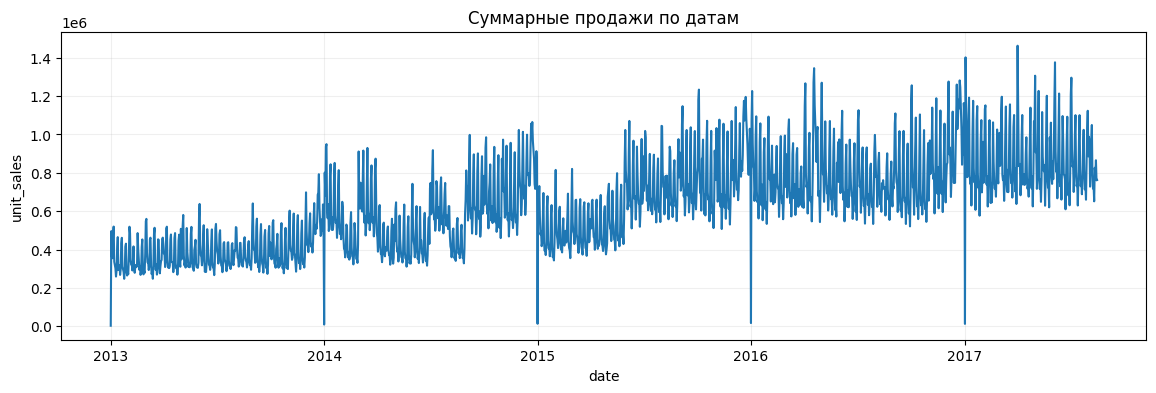

In [8]:

daily_total = train.groupby("date", as_index=False)["unit_sales"].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily_total["date"], daily_total["unit_sales"])
plt.title("Суммарные продажи по датам")
plt.xlabel("date")
plt.ylabel("unit_sales")
plt.grid(True, alpha=0.2)
plt.show()

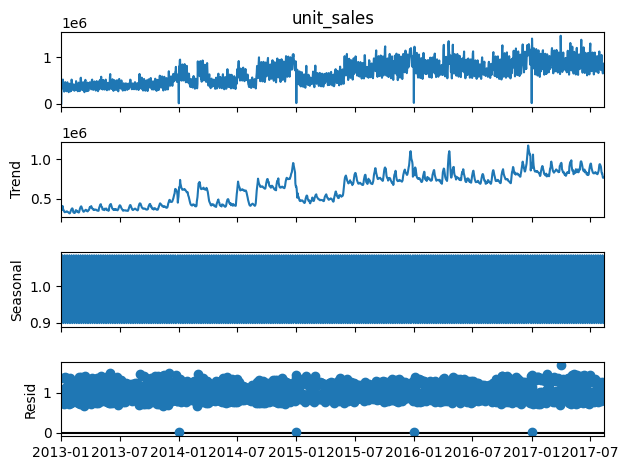

In [9]:

series = daily_total.set_index("date")["unit_sales"]

decomp = seasonal_decompose(series, model="multiplicative", period=7)

decomp.plot()
plt.show()


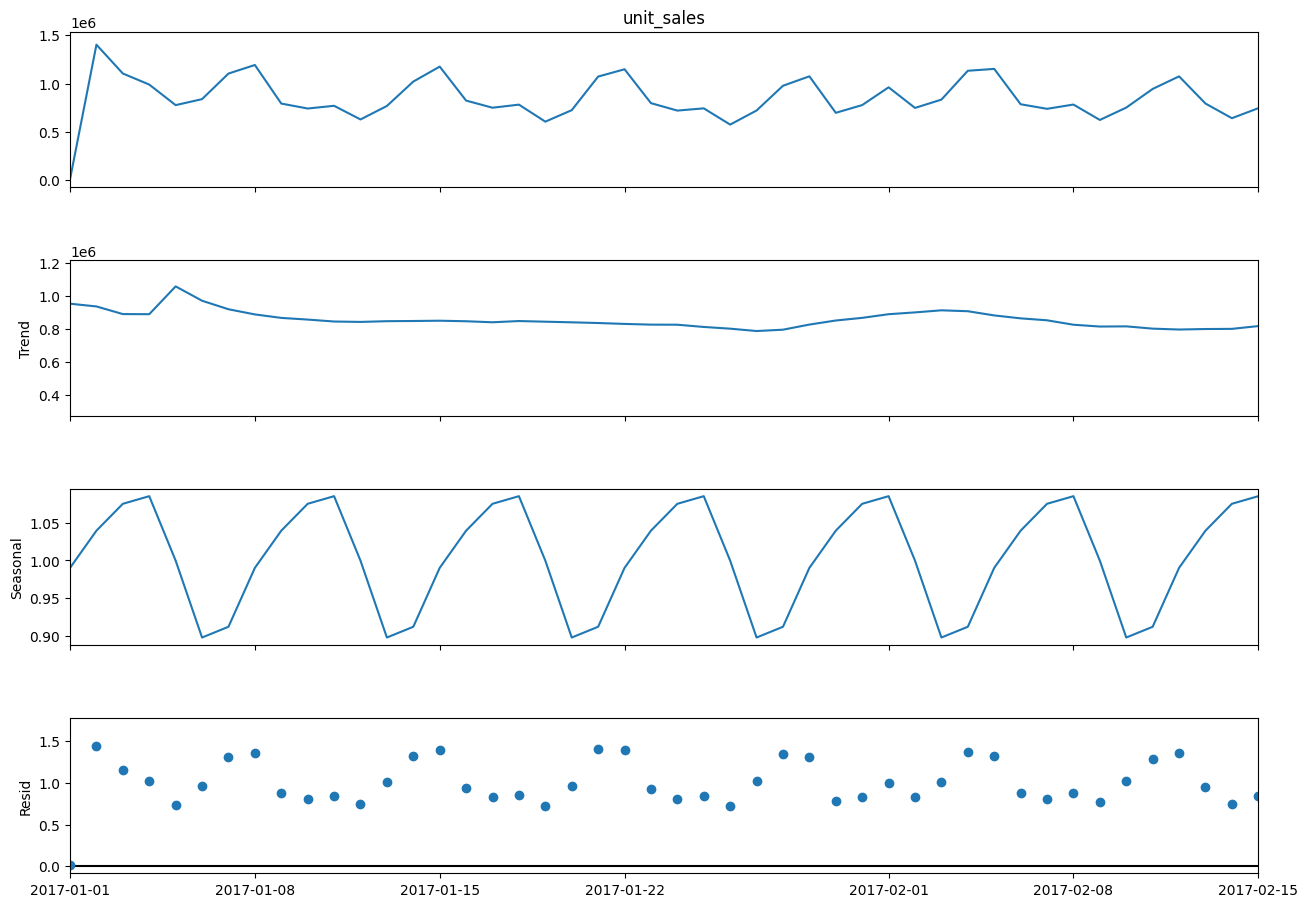

In [10]:
decomp = seasonal_decompose(series, model="multiplicative", period=7)

fig = decomp.plot()
fig.set_size_inches(14, 10)

for ax in fig.axes:
    ax.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2017-02-15"))

plt.show()


### Анализ сезонности

Для анализа структуры временного ряда была выполнена сезонная декомпозиция с периодом 7 дней.

Результаты показывают:

1. **Наличие выраженной недельной сезонности.**  
   Сезонная компонента демонстрирует повторяющийся шаблон с периодом 7 дней. Продажи минимальны в начале недели и достигают максимума в выходные дни.

2. **Мультипликативный характер сезонности.**  
   Амплитуда сезонных колебаний составляет примерно 20%, что указывает на мультипликативную структуру ряда.

3. **Стабильный тренд на коротком интервале.**  
   На выбранном временном интервале тренд практически не изменяется, что означает, что основные колебания объясняются сезонностью.

Полученные результаты подтверждают необходимость использования признаков, связанных с днем недели и лаговыми значениями продаж (например, lag_7 и lag_14).


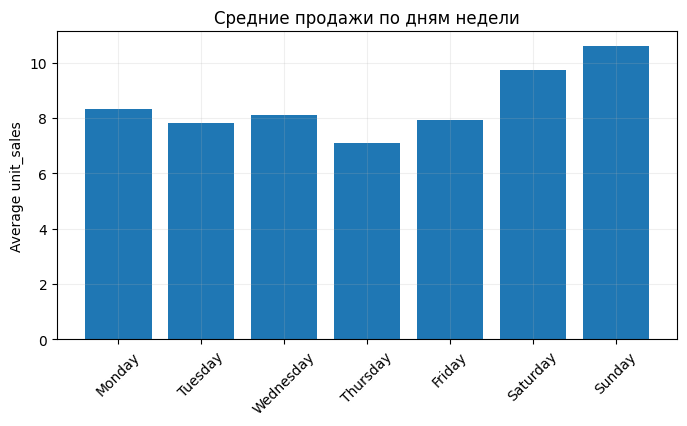

In [11]:
train["dow"] = train["date"].dt.day_name()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_mean = (
    train.groupby("dow")["unit_sales"]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(8,4))
plt.bar(dow_mean.index, dow_mean.values)
plt.title("Средние продажи по дням недели")
plt.ylabel("Average unit_sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.show()


<Figure size 1000x400 with 0 Axes>

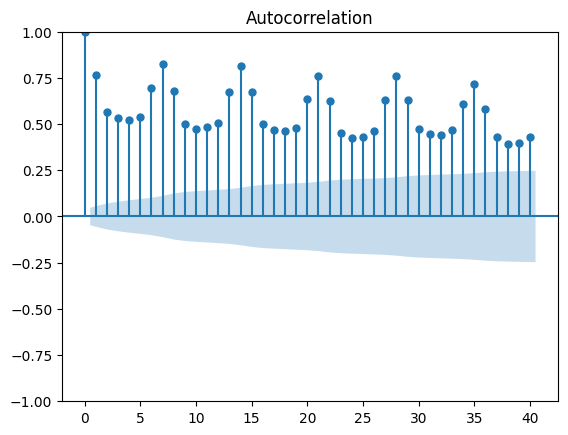

In [13]:

plt.figure(figsize=(10,4))
plot_acf(series.dropna(), lags=40)
plt.show()


<Figure size 1000x400 with 0 Axes>

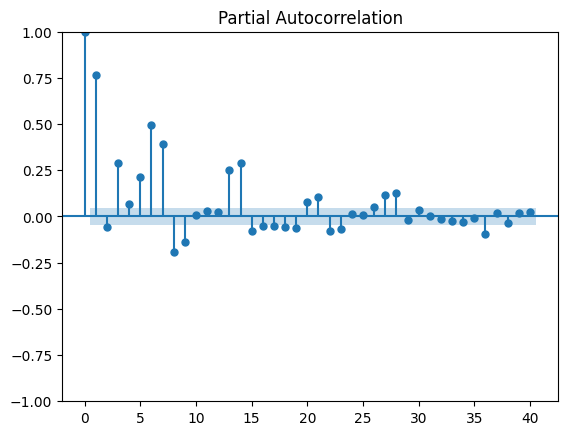

In [15]:

plt.figure(figsize=(10,4))
plot_pacf(series.dropna(), lags=40)
plt.show()


### Автокорреляционный анализ

Для анализа временной зависимости в данных была построена функция автокорреляции (ACF).

Результаты показывают несколько важных особенностей:

1. **Высокая автокорреляция на малых лагах.**  
   Значение ACF(1) значительно больше нуля, что указывает на сильную краткосрочную зависимость продаж.

2. **Выраженные пики на лагах 7, 14, 21 и 28.**  
   Это свидетельствует о наличии недельной сезонности. Продажи в определённый день недели похожи на продажи в тот же день недели в предыдущие недели.

3. **Статистическая значимость автокорреляций.**  
   Большинство лагов находятся за пределами доверительного интервала, что подтверждает наличие структурированной зависимости во временном ряду.

Полученные результаты подтверждают целесообразность использования лаговых признаков (lag_1, lag_7, lag_14) при построении моделей прогнозирования.

### Анализ частичной автокорреляции

Для определения прямой зависимости между текущими и прошлыми значениями временного ряда была построена функция частичной автокорреляции (PACF).

Анализ показывает:

1. **Сильную зависимость на лаге 1.**  
   Значение PACF(1) значительно превышает доверительный интервал, что указывает на сильную краткосрочную зависимость продаж.

2. **Наличие сезонных лагов.**  
   Наблюдаются значимые пики около лагов 7 и 14, что соответствует недельной сезонности.

3. **Убывание значимости на больших лагах.**  
   После примерно 10–15 лагов значения PACF становятся статистически незначимыми, что говорит о том, что дальние лаги не добавляют существенной информации.

Таким образом, анализ PACF подтверждает целесообразность использования лаговых признаков (lag_1, lag_7, lag_14) при построении моделей прогнозирования.
